** Подключение библиотек**


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)


**Раздел 1. Загрузка данных и первичный осмотр**

In [13]:
df = pd.read_csv('dataset_telecom.csv')
print('Размерность:', df.shape)
display(df.head(2))
df.info()
display(df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(2))

Размерность: (4492, 11)


,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонков ночью за месяц,Звонки в другие города,Звонки в другие страны,Доля звонков на стационарные телефоны,Количество SMS за месяц,Дата подключения тарифа
0,24,NaN,2.4,12.0,65.0,5,0,0,5,56,2018-06-17 12:14:35
1,51,287.51,1.7,111.0,109.0,1,44,0,6,1,2021-10-21 15:39:54


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Возраст                                4492 non-null   int64  
 1   Среднемесячный расход                  4468 non-null   float64
 2   Средняя продолжительность разговоров   4475 non-null   float64
 3   Звонков днем за месяц                  4472 non-null   float64
 4   Звонков вечером за месяц               4489 non-null   float64
 5   Звонков ночью за месяц                 4492 non-null   object 
 6   Звонки в другие города                 4492 non-null   object 
 7   Звонки в другие страны                 4492 non-null   int64  
 8   Доля звонков на стационарные телефоны  4492 non-null   object 
 9   Количество SMS за месяц                4492 non-null   object 
 10  Дата подключения тарифа                4492 non-null   object 
dtypes: f

,count,mean,std,min,1%,25%,50%,75%,99%,max
Возраст,4492.0,41.89,13.08,19.00,19.00,31.00,43.00,52.00,69.00,70.00
Среднемесячный расход,4468.0,505.53,646.35,3.18,7.79,152.49,315.51,599.84,3544.90,5142.76
Средняя продолжительность разговоров,4475.0,4.23,3.01,0.10,0.40,2.10,3.30,5.90,14.45,20.00
Звонков днем за месяц,4472.0,63.90,62.88,1.00,2.00,37.00,53.00,68.00,391.16,500.00
Звонков вечером за месяц,4489.0,70.36,41.22,1.00,2.00,42.00,71.00,98.00,156.00,160.00
Звонки в другие страны,4492.0,0.39,1.17,0.00,0.00,0.00,0.00,0.00,6.00,12.00


Вывод:
- Четыре признака нужно привести к числу — иначе они не попадут ни в один
расчёт.
- Дата подключения формата-текст, её нужно приводить к типу.
- У расхода 99-й перцентиль (3 544,90) в одиннадцать раз больше медианы (315,51)
— длинный правый хвост.

**Раздел 2. Предварительная обработка  /  2.1. Корректировка заголовков**

In [14]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.rename(columns={
    'среднемесячный_расход': 'расход',
    'средняя_продолжительность_разговоров': 'длительность',
    'звонков_днем_за_месяц': 'звонки_день',
    'звонков_вечером_за_месяц': 'звонки_вечер',
    'звонков_ночью_за_месяц': 'звонки_ночь',
    'звонки_в_другие_города': 'звонки_город',
    'звонки_в_другие_страны': 'звонки_страны',
    'доля_звонков_на_стационарные_телефоны': 'доля_стационар',
    'количество_sms_за_месяц': 'sms',
    'дата_подключения_тарифа': 'дата_подключения',
}, inplace=True)

print(list(df.columns))

['возраст', 'расход', 'длительность', 'звонки_день', 'звонки_вечер', 'звонки_ночь', 'звонки_город', 'звонки_страны', 'доля_стационар', 'sms', 'дата_подключения']


**Раздел 2. Предварительная обработка  /  2.2. Корректировка типов**

In [15]:
for col in ['звонки_ночь', 'звонки_город', 'доля_стационар', 'sms']:
    bad = df[col].astype(str).str.contains("'")
    print(col, '— значений с апострофом:', bad.sum(), '|', df.loc[bad, col].tolist())


звонки_ночь — значений с апострофом: 1 | ["'7'"]
звонки_город — значений с апострофом: 2 | ["'29'", "'0'"]
доля_стационар — значений с апострофом: 1 | ["'2'"]
sms — значений с апострофом: 1 | ["'12'"]


Вывод: при загрузке четыре количественных признака — «Звонков ночью
за месяц», «Звонки в другие города», «Доля звонков на стационарные
телефоны» и «Количество SMS за месяц» — были распознаны как текстовые.
Причина: пять отдельных значений записаны в апострофах (&#39;7&#39;, &#39;29&#39;, &#39;0&#39;, &#39;2&#39;,
&#39;12&#39;), из-за чего pandas не смог определить числовой тип всего столбца.
Апострофы удалены, признаки приведены к целочисленному типу. Без этой
операции четыре признака не попали бы ни в описательные статистики, ни в
расчёты средних, при этом никакой ошибки бы не возникло.

**Раздел 2. Предварительная обработка  /  2.2. Корректировка типов (продолжение)**

In [16]:
for col in ['звонки_ночь', 'звонки_город', 'доля_стационар', 'sms']:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip("'"))

df['дата_подключения'] = pd.to_datetime(df['дата_подключения'])

print(df.dtypes)
print('Диапазон дат:', df['дата_подключения'].min(), '—', df['дата_подключения'].max())


возраст                      int64
расход                     float64
длительность               float64
звонки_день                float64
звонки_вечер               float64
звонки_ночь                  int64
звонки_город                 int64
звонки_страны                int64
доля_стационар               int64
sms                          int64
дата_подключения    datetime64[ns]
dtype: object
Диапазон дат: 2015-01-01 15:48:33 — 2021-12-31 14:12:11


Вывод: коррекция типов потребовалась для пяти признаков. Дата
подключения тарифа приведена к типу datetime64 — это необходимое
условие для Шага 3, где из неё извлекаются год, месяц и число. Четыре
счётчика звонков и SMS приведены к целому типу после удаления
апострофов, попавших в отдельные ячейки при выгрузке данных.

**Раздел 2. Предварительная обработка  /  2.3. Проверка дублирующихся записей**

In [17]:
print('Полных дублей:', df.duplicated().sum())
print('Дублей без даты подключения:',
      df.drop(columns=['дата_подключения']).duplicated().sum())


Полных дублей: 0
Дублей без даты подключения: 0


Комментарий вторая проверка нужна потому что дата с точностью до секунды делает любую строку
уникальной и может замаскировать реальные повторы. Здесь она ничего не находит,

**Раздел 2. Предварительная обработка  /  2.4. Проверка аномальных значений**

In [18]:
continuous = ['возраст', 'расход', 'длительность', 'звонки_день', 'звонки_вечер',
              'звонки_ночь', 'звонки_город', 'звонки_страны', 'доля_стационар', 'sms']

def get_whiskers(s):
    """Возвращает кортеж (нижний ус, верхний ус) для серии s."""
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return s[s >= q1 - 1.5 * iqr].min(), s[s <= q3 + 1.5 * iqr].max()

rows, mask = [], pd.Series(True, index=df.index)

for col in continuous:
    lw, uw = get_whiskers(df[col])
    inside = df[col].between(lw, uw)
    rows.append([col, round(lw, 2), round(uw, 2),
                 round(df[col].quantile(0.01), 2), round(df[col].quantile(0.99), 2),
                 int((~inside & df[col].notna()).sum())])
    mask &= inside | df[col].isna()

anom = pd.DataFrame(rows, columns=['признак', 'нижний_ус', 'верхний_ус',
                                   'перц_1', 'перц_99', 'за_усами'])
anom['доля_%'] = (anom['за_усами'] / len(df) * 100).round(2)
display(anom)

print('Если отфильтровать по всем признакам сразу:', mask.sum(), 'строк из', len(df),
      f'— потери {100 - mask.sum() / len(df) * 100:.1f} %')

print('Отрицательных значений:', int((df[continuous] < 0).sum().sum()),
      '| доля стационарных > 100:', int((df['доля_стационар'] > 100).sum()),
      '| возраст вне [19; 70]:', int((~df['возраст'].between(19, 70)).sum()))


,признак,нижний_ус,верхний_ус,перц_1,перц_99,за_усами,доля_%
0,возраст,19.00,70.00,19.00,69.00,0,0.00
1,расход,3.18,1270.16,7.79,3544.90,325,7.24
2,длительность,0.10,11.60,0.40,14.45,125,2.78
3,звонки_день,1.00,114.00,2.00,391.16,272,6.06
4,звонки_вечер,1.00,160.00,2.00,156.00,0,0.00
5,звонки_ночь,0.00,12.00,0.00,84.00,521,11.60
6,звонки_город,0.00,30.00,0.00,46.09,494,11.00
7,звонки_страны,0.00,0.00,0.00,6.00,823,18.32
8,доля_стационар,0.00,35.00,0.00,36.09,49,1.09
9,sms,0.00,75.00,0.00,122.00,239,5.32


Если отфильтровать по всем признакам сразу: 2878 строк из 4492 — потери 35.9 %
Отрицательных значений: 0 | доля стационарных > 100: 0 | возраст вне [19; 70]: 0


Вывод: явных ошибок в данных не обнаружено: отрицательных значений нет, доля
звонков на стационарные телефоны нигде не превышает 100 %, возраст
лежит в диапазоне 19–70 лет, дат из будущего нет.
Признаки «возраст» и «звонки вечером» аномальных значений по правилу
усов не содержат вовсе. У признаков «звонки ночью», «звонки в другие
города», «звонки в другие страны», «доля звонков на стационарные
телефоны» и «SMS» большинство клиентов имеет нулевое значение, поэтому
межквартильный размах вырождается, и правило усов относит к аномалиям
всех клиентов, пользовавшихся услугой. Крайний случай — «звонки в другие
страны»: оба уса равны нулю, в «аномалии» попадает 18,3 % набора. Это не
ошибки данных, а особенность распределения признака.
Сплошная фильтрация по усам оставила бы 2 878 строк из 4 492 (потери 35,9
%), что недопустимо. Аномальные значения не удаляются: длинные правые
хвосты у расхода, дневных звонков и SMS отражают реальную
неоднородность клиентской базы и представляют самостоятельный интерес
для сегментации.

**Раздел 2. Предварительная обработка  /  2.4. Проверка аномальных значений   (продолжение - визуализация)**

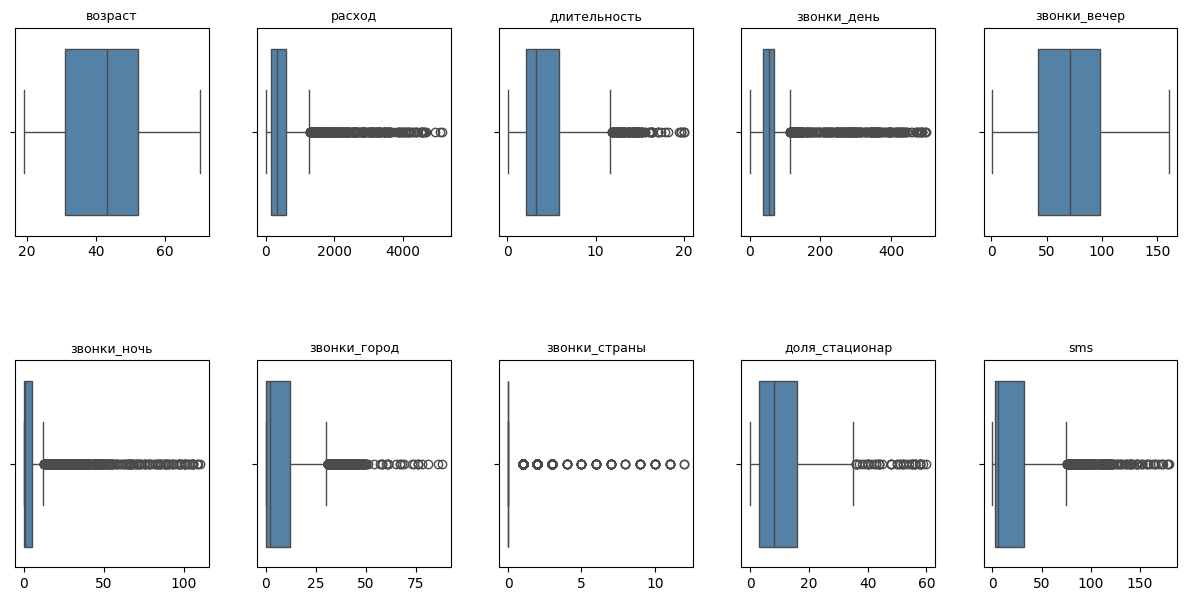

In [21]:
plt.figure(figsize=(15, 7))
plt.subplots_adjust(hspace=0.6, wspace=0.25)

for k, col in enumerate(continuous, start=1):
    plt.subplot(2, 5, k)
    sns.boxplot(x=df[col], color='steelblue')
    plt.title(col, fontsize=9)
    plt.xlabel('')

plt.show()

**Раздел 2. Предварительная обработка  /  2.5. Восстановление пропущенных значений**

In [22]:
print(df.isna().sum())

n_na = df.isna().any(axis=1).sum()
print(f'Строк хотя бы с одним пропуском: {n_na} ({round(n_na / len(df) * 100, 2)} %)')

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Было {before}, стало {len(df)}, удалено {before - len(df)}')


возраст              0
расход              24
длительность        17
звонки_день         20
звонки_вечер         3
звонки_ночь          0
звонки_город         0
звонки_страны        0
доля_стационар       0
sms                  0
дата_подключения     0
dtype: int64
Строк хотя бы с одним пропуском: 62 (1.38 %)
Было 4492, стало 4430, удалено 62


Вывод: пропуски присутствуют в четырёх признаках и составляют 1,38 %
набора (62 строки из 4 492). Восстановление медианой или модой нецелесообразно:
объём пропусков мал, а заполнение модой искусственно увеличивает пик распределения
и искажает описательные статистики. Строки с пропусками удалены, для дальнейшего
анализа используется 4 430 записей.

**Раздел 3. Добавление новых переменных  /  3.1. Возрастная категория**

In [23]:
def age_category(age):
    """Возрастная категория клиента по значению возраста."""
    if 19 <= age <= 24:
        return 'студент'
    elif 25 <= age <= 33:
        return 'аспирант'
    elif 34 <= age <= 56:
        return 'бизнесмен'
    elif 57 <= age <= 70:
        return 'знаток'
    return 'не определена'

df['возрастная_категория'] = df['возраст'].apply(age_category)

print(df['возрастная_категория'].value_counts())
print('Не определена:', int((df['возрастная_категория'] == 'не определена').sum()))

возрастная_категория
бизнесмен    2449
аспирант      819
знаток        651
студент       511
Name: count, dtype: int64
Не определена: 0


**Раздел 3. Добавление новых переменных /  3.2. Год, месяц и число подключения**

In [24]:
df['год_подключения'] = df['дата_подключения'].dt.year
df['месяц_подключения'] = df['дата_подключения'].dt.month
df['день_подключения'] = df['дата_подключения'].dt.day

display(df[['дата_подключения', 'год_подключения',
            'месяц_подключения', 'день_подключения']].head(3))

,дата_подключения,год_подключения,месяц_подключения,день_подключения
0,2021-10-21 15:39:54,2021,10,21
1,2015-03-26 11:26:15,2015,3,26
2,2016-01-04 15:53:20,2016,1,4


**Раздел 4. Исследовательский анализ данных**

In [26]:
order = ['студент', 'аспирант', 'бизнесмен', 'знаток']

**Раздел 4. Исследовательский анализ данных  /  4.1. Динамика подключения к тарифам**

год_подключения
2015    583
2016    641
2017    668
2018    671
2019    592
2020    634
2021    641
Name: count, dtype: int64
Год: min 2015 583 | max 2018 671
Месяц: min 3 330 | max 8 418
День: min 31 71 | max 22 177


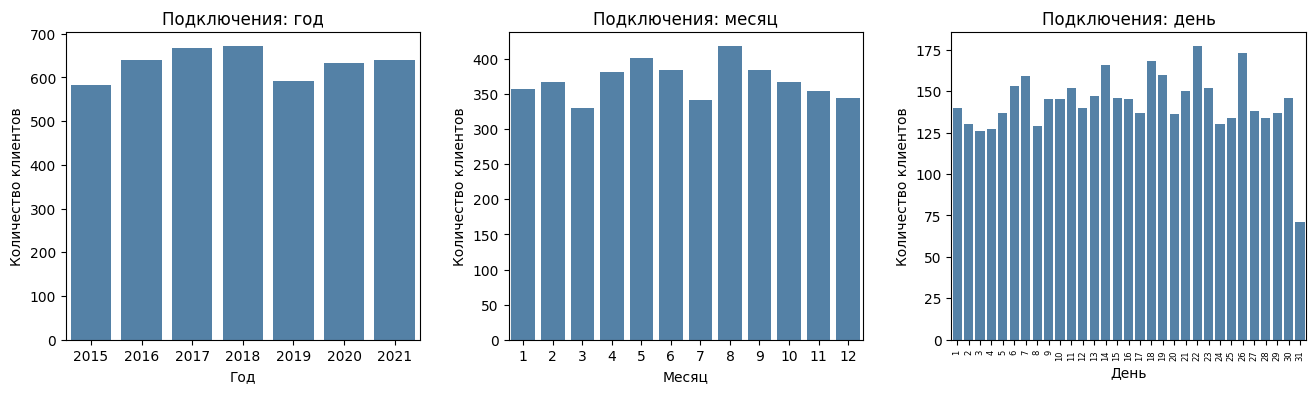

In [27]:
by_year = df['год_подключения'].value_counts().sort_index()
by_month = df['месяц_подключения'].value_counts().sort_index()
by_day = df['день_подключения'].value_counts().sort_index()

print(by_year)
print('Год: min', by_year.idxmin(), by_year.min(), '| max', by_year.idxmax(), by_year.max())
print('Месяц: min', by_month.idxmin(), by_month.min(), '| max', by_month.idxmax(), by_month.max())
print('День: min', by_day.idxmin(), by_day.min(), '| max', by_day.idxmax(), by_day.max())

plt.figure(figsize=(16, 4))
plt.subplots_adjust(wspace=0.25)

for k, (data, name) in enumerate([(by_year, 'Год'), (by_month, 'Месяц'),
                                  (by_day, 'День')], start=1):
    plt.subplot(1, 3, k)
    sns.barplot(x=data.index, y=data.values, color='steelblue')
    plt.title(f'Подключения: {name.lower()}')
    plt.xlabel(name)
    plt.ylabel('Количество клиентов')
    if name == 'День':
        plt.xticks(fontsize=6, rotation=90)

plt.show()

Вывод: подключения распределены по годам практически равномерно: доля каждого
года составляет от 13,2 % до 15,2 % набора. Минимум приходится на 2015 год
(583 клиента), максимум — на 2018-й (671), однако 2017 и 2018 годы
фактически неразличимы (668 и 671), поэтому говорить о годе-рекордсмене
некорректно. Ни возрастающего тренда, ни спада данные не показывают.
По месяцам минимум приходится на март (330), максимум — на август (418),
отклонения от среднего лежат в пределах ±13 %. Устойчивой сезонной волны
не наблюдается.
В разрезе чисел месяца выделяется 31-е: 71 подключение против ~143 в
среднем. Причина техническая — 31-е число есть только в семи месяцах из
двенадцати.
Общий вывод: динамика подключений стабильна, для планирования
маркетинговых кампаний в разрезе календаря данные оснований не дают.

**Раздел 4. Исследовательский анализ данных  /  4.2. Распределения признаков по возрастным категориям**

In [28]:
features = ['расход', 'длительность', 'звонки_день', 'звонки_вечер',
            'звонки_ночь', 'звонки_город', 'доля_стационар', 'sms']

g = df.groupby('возрастная_категория')[features]

summary = pd.concat([g.mean().reindex(order).T,
                     g.median().reindex(order).T,
                     g.agg(lambda s: s.mode().iloc[0]).reindex(order).T],
                    axis=1, keys=['среднее', 'медиана', 'мода']).round(2)
display(summary)

среднее                            медиана                               мода                          
возрастная_категория студент аспирант бизнесмен  знаток студент аспирант бизнесмен  знаток студент аспирант бизнесмен знаток
расход                231.08   701.15    515.01  445.00  136.76   463.74    337.74  227.03    9.94   267.54     13.92   16.8
длительность            2.82     5.37      4.27    3.72    2.40     4.40      3.40    2.80    3.00     2.40      1.70    2.5
звонки_день            37.89    80.50     65.64   56.93   35.00    63.00     55.00   44.00   32.00    55.00     62.00    5.0
звонки_вечер           68.59    85.33     69.82   54.50   70.00    85.00     69.00   52.00   61.00    76.00      4.00    3.0
звонки_ночь             9.95    14.29      3.91    2.09    7.00     3.00      0.00    0.00    0.00     0.00      0.00    0.0
звонки_город            1.05    11.26      9.88    6.92    0.00     5.00      3.00    0.00    0.00     0.00      0.00    0.0
доля_стационар          4.01    11.31     11.24   10.65    3.00    10.00     10.00    8.00    0.00     0.00      0.00    4.0
sms                    48.37    38.50     14.58    2.75   41.00    28.00      5.00    3.00   31.00    14.00      0.00    3.0

Вывод: студент — минимальный чек (231 руб.),
максимум SMS (48,4), ночная активность, почти нет междугородних звонков.

Аспирант — самая дорогая и самая активная группа по всем видам голосовой
связи: расход 701 руб., 80,5 дневных и 85,3 вечерних звонка, максимум
междугородних (11,3) и максимум ночных (14,3). Бизнесмен — самая
массовая группа (55 % базы), устойчивое среднее по всем показателям без
выраженных пиков. Знаток — почти не пользуется SMS (2,8) и ночной связью
(2,1), меньше всех звонит вечером (54,5), но расход 445 руб. — вдвое выше,
чем у студентов. Отдельно отмечу, что знатоки — единственная категория, у
которой вечерних звонков меньше, чем дневных (54,5 против 56,9); у всех
остальных вечер активнее дня.

**Раздел 4. Исследовательский анализ данных  /  4.2. Распределения признаков по возрастным категориям   (продолжение)**

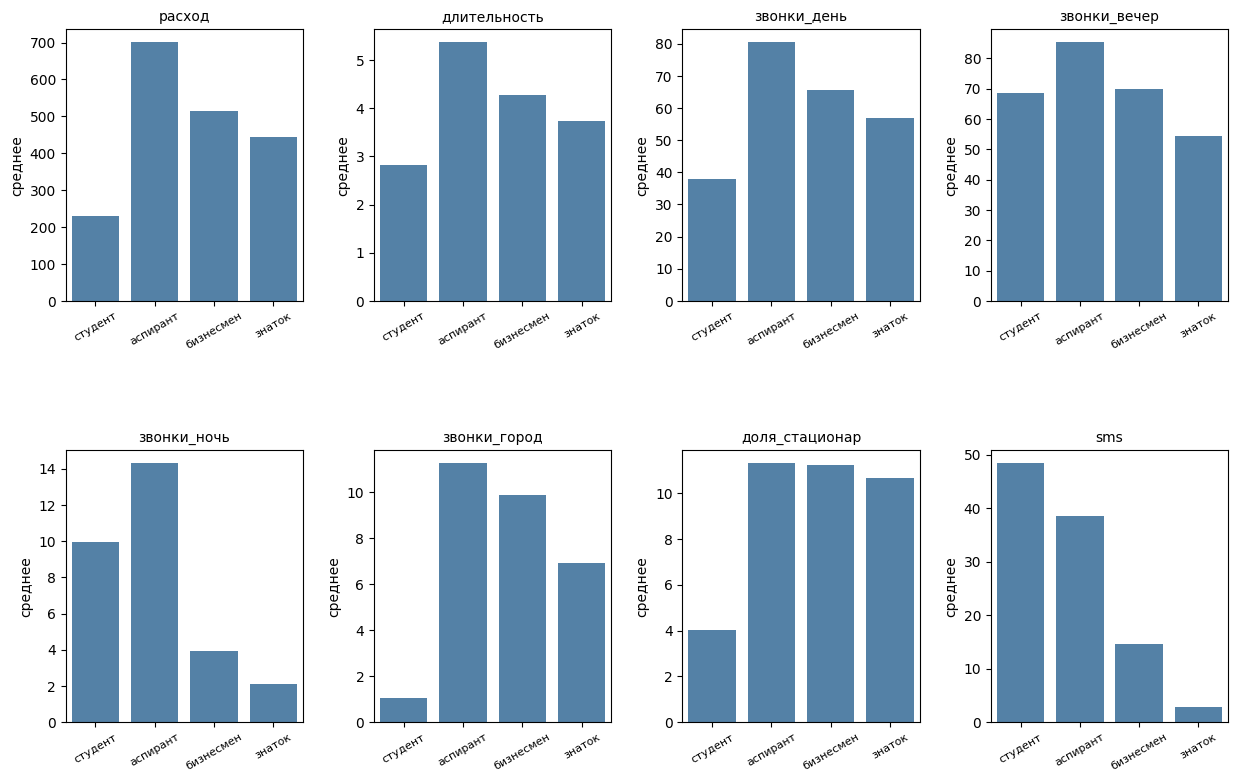

In [29]:
plt.figure(figsize=(15, 9))
plt.subplots_adjust(hspace=0.55, wspace=0.3)

for k, col in enumerate(features, start=1):
    means = df.groupby('возрастная_категория')[col].mean().reindex(order)
    plt.subplot(2, 4, k)
    sns.barplot(x=means.index, y=means.values, color='steelblue')
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.ylabel('среднее')
    plt.xticks(rotation=30, fontsize=8)

plt.show()

Вывод: cамая сильная и единственная строго
монотонная закономерность набора — количество SMS: 48,4 у студентов, 38,5
у аспирантов, 14,6 у бизнесменов, 2,8 у знатоков, разница между крайними
группами в 17,6 раза. Голосовая активность ведёт себя иначе: расход,
длительность разговора и число дневных звонков достигают максимума не у
самых молодых, а у аспирантов. Иными словами, младшие категории
выбирают текстовые сообщения, старшие — голос. Ночная активность резко
разделяет группы: 14,3 звонка у аспирантов и 10,0 у студентов против 3,9 у
бизнесменов и 2,1 у знатоков. Звонки в другие города у студентов практически
отсутствуют (1,05 в среднем, медиана 0), а доля звонков на стационарные
телефоны у них почти втрое ниже, чем у остальных (4,0 против 10,7–11,3).
Практически у всех признаков среднее заметно выше медианы —
распределения вытянуты вправо, и опираться в выводах следует на медиану.

**Раздел 4. Исследовательский анализ данных  /  4.2. Распределения признаков по возрастным категориям, визуализация**

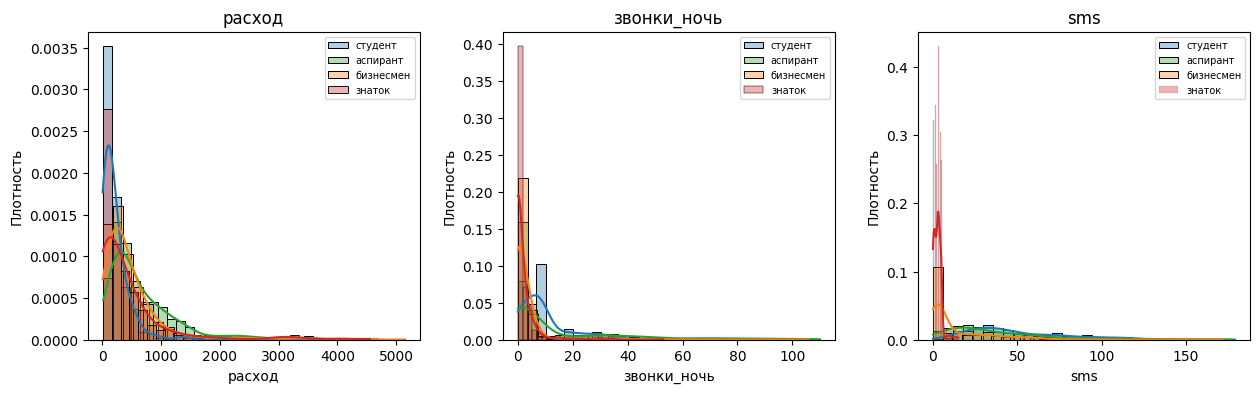

In [30]:
colors = dict(zip(order, ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']))

plt.figure(figsize=(15, 4))
plt.subplots_adjust(wspace=0.25)

for k, col in enumerate(['расход', 'звонки_ночь', 'sms'], start=1):
    plt.subplot(1, 3, k)
    for cat in order:
        sns.histplot(df.loc[df['возрастная_категория'] == cat, col],
                     bins=30, kde=True, stat='density',
                     color=colors[cat], alpha=0.35, label=cat)
    plt.title(col)
    plt.ylabel('Плотность')
    plt.legend(fontsize=7)

plt.show()

**Раздел 4. Исследовательский анализ данных  /  4.3. ТОП-2 возрастных категорий**

In [31]:
for part, col in [('день', 'звонки_день'), ('вечер', 'звонки_вечер'), ('ночь', 'звонки_ночь')]:
    df['время_' + part] = df[col] * df['длительность']

top_cols = ['расход', 'время_день', 'время_вечер', 'время_ночь',
            'звонки_день', 'звонки_вечер', 'звонки_ночь']

top = df.groupby('возрастная_категория')[top_cols].mean().reindex(order).round(2)
display(top)

for col in top_cols:
    print(f'{col:14} → ТОП-2:', list(top[col].sort_values(ascending=False).index[:2]))

,расход,время_день,время_вечер,время_ночь,звонки_день,звонки_вечер,звонки_ночь
возрастная_категория,,,,,,,
студент,231.08,137.16,202.85,35.17,37.89,68.59,9.95
аспирант,701.15,523.02,494.84,115.61,80.50,85.33,14.29
бизнесмен,515.01,370.53,332.29,29.61,65.64,69.82,3.91
знаток,445.00,343.14,260.89,15.25,56.93,54.50,2.09


расход         → ТОП-2: ['аспирант', 'бизнесмен']
время_день     → ТОП-2: ['аспирант', 'бизнесмен']
время_вечер    → ТОП-2: ['аспирант', 'бизнесмен']
время_ночь     → ТОП-2: ['аспирант', 'студент']
звонки_день    → ТОП-2: ['аспирант', 'бизнесмен']
звонки_вечер   → ТОП-2: ['аспирант', 'бизнесмен']
звонки_ночь    → ТОП-2: ['аспирант', 'студент']


Вывод: ТОП-2 по среднемесячному расходу — аспиранты (701,15) и бизнесмены
(515,01). ТОП-2 по времени общения: днём и вечером — аспиранты (523,0 и
494,8 мин.) и бизнесмены (370,5 и 332,3 мин.); ночью — аспиранты (115,6
мин.) и студенты (35,2 мин.). ТОП-2 по количеству звонков полностью
совпадает с ТОП-2 по времени общения во всех трёх интервалах.
В наборе только один признак продолжительности
разговора — общий для всего дня, поэтому при переходе от количества
звонков ко времени все три показателя клиента умножаются на одно и то же
число. Порядок мог бы измениться лишь в том случае, если бы у категории с
меньшим числом звонков была заметно большая длительность разговора.
Здесь этого не происходит: аспиранты лидируют одновременно и по числу
звонков, и по длительности (5,37 мин. против 4,27 у бизнесменов).
Единственное содержательное отличие ночного интервала — вместо
бизнесменов на второе место выходят студенты. Ночная активность
оказывается возрастной характеристикой: она максимальна у двух младших
категорий и падает почти в семь раз к старшим.

**Раздел 4. Исследовательский анализ данных  /  4.4. Диаграммы рассеивания и корреляции**

,расход,длительность,звонки_день,звонки_вечер,звонки_ночь,звонки_город,доля_стационар,sms
расход,1.00,0.83,0.84,0.42,0.39,0.34,0.36,0.09
длительность,0.83,1.00,0.52,0.32,0.40,0.26,0.24,0.18
звонки_день,0.84,0.52,1.00,0.31,0.32,0.37,0.42,0.03
звонки_вечер,0.42,0.32,0.31,1.00,0.28,0.20,0.20,0.23
звонки_ночь,0.39,0.40,0.32,0.28,1.00,0.14,-0.01,0.51
звонки_город,0.34,0.26,0.37,0.20,0.14,1.00,0.26,0.02
доля_стационар,0.36,0.24,0.42,0.20,-0.01,0.26,1.00,-0.12
sms,0.09,0.18,0.03,0.23,0.51,0.02,-0.12,1.00


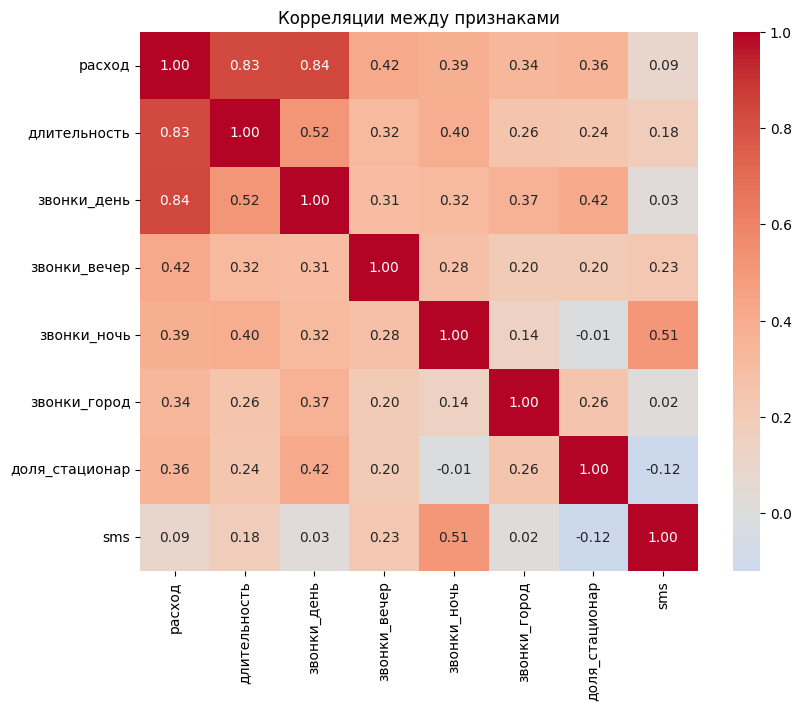

In [32]:
features = ['расход', 'длительность', 'звонки_день', 'звонки_вечер',
            'звонки_ночь', 'звонки_город', 'доля_стационар', 'sms']

corr = df[features].corr().round(2)
display(corr)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляции между признаками')
plt.show()

Вывод: диаграммы рассеивания выявили две группы связей. Первая —
сильные положительные связи расхода с дневными звонками (r = 0,84) и с
длительностью разговора (r = 0,83). Содержательно они почти тавтологичны:
расход и складывается из количества и длительности разговоров, — но эта
проверка полезна как контроль согласованности данных: если бы связь
отсутствовала, это указывало бы на ошибку в выгрузке. Вторая группа
интереснее: количество ночных звонков связано с количеством SMS (r = 0,51)
сильнее, чем с любым другим признаком, тогда как с дневной активностью
SMS не связаны совсем (r = 0,03), а с долей звонков на стационарные
телефоны связаны слабо отрицательно (r = −0,12). То есть ночная связь и
текстовые сообщения образуют единый поведенческий профиль, и профиль
этот, как показано в п. 4.2, принадлежит двум младшим возрастным
категориям.

**Раздел 4. Исследовательский анализ данных  /  4.4. Диаграммы рассеивания и корреляции (продолжение)**

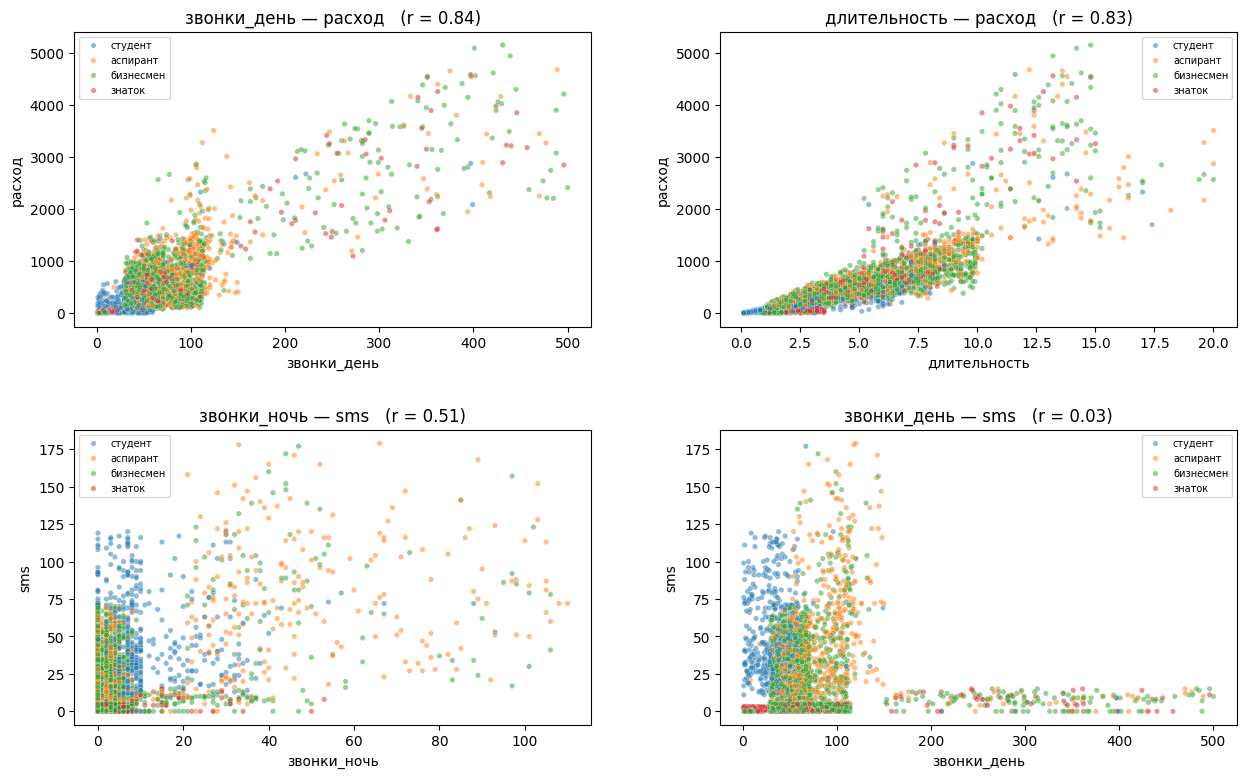

In [33]:
pairs = [('звонки_день', 'расход'),
         ('длительность', 'расход'),
         ('звонки_ночь', 'sms'),
         ('звонки_день', 'sms')]

plt.figure(figsize=(15, 9))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

for k, (x, y) in enumerate(pairs, start=1):
    plt.subplot(2, 2, k)
    sns.scatterplot(data=df, x=x, y=y, hue='возрастная_категория',
                    hue_order=order, alpha=0.5, s=15)
    r = df[x].corr(df[y])
    plt.title(f'{x} — {y}   (r = {r:.2f})')
    plt.legend(fontsize=7)

plt.show()

Вывод: на диаграммах рассеивания «расход — дневные звонки» и
«расход — длительность» точки образуют выраженное облако с
положительным наклоном, что подтверждается коэффициентами корреляции
0,84 и 0,83. При раскраске точек по возрастной категории видно, что верхнюю
часть облака формируют аспиранты, а нижнюю — студенты. На диаграмме
«ночные звонки — SMS» (r = 0,51) точки студентов и аспирантов
сосредоточены в правой верхней области, а бизнесмены и знатоки прижаты к
началу координат. Наиболее показательна диаграмма «дневные звонки —
SMS»: облако точек не имеет наклона (r = 0,03), то есть эти две услуги
потребляются полностью независимо. Практический смысл: пакеты SMS
нельзя привязывать к объёму голосового трафика — это самостоятельная
потребность самостоятельной группы клиентов.

**Раздел 5. Гипотеза и её проверка /  5.1. Доверительный интервал для среднего расхода**

In [34]:
mean = df['расход'].mean()
std = df['расход'].std()
n = len(df)
se = std / np.sqrt(n)

print('Средний расход: %.2f руб.' % mean)
print('95%%-й доверительный интервал: [%.2f; %.2f]' % (mean - 1.96 * se, mean + 1.96 * se))

Средний расход: 506.38 руб.
95%-й доверительный интервал: [487.29; 525.47]


**Раздел 5. Гипотеза и её проверка /  5.2. Гипотеза 1 — о расходах аспирантов и бизнесменов**

In [35]:
a = df.loc[df['возрастная_категория'] == 'аспирант', 'расход']
b = df.loc[df['возрастная_категория'] == 'бизнесмен', 'расход']

t_stat, p_t = st.ttest_ind(a, b, equal_var=False)
u_stat, p_mw = st.mannwhitneyu(a, b)

print('Средние: аспиранты %.2f, бизнесмены %.2f' % (a.mean(), b.mean()))
print('Медианы: аспиранты %.2f, бизнесмены %.2f' % (a.median(), b.median()))
print('t-критерий: p = %.3g' % p_t)
print('Критерий Манна–Уитни: p = %.3g' % p_mw)
print('Вывод:', 'H0 отвергаем' if p_t < 0.05 else 'H0 не отвергаем')

Средние: аспиранты 701.15, бизнесмены 515.01
Медианы: аспиранты 463.74, бизнесмены 337.74
t-критерий: p = 2.37e-11
Критерий Манна–Уитни: p = 3.95e-23
Вывод: H0 отвергаем


**Раздел 5. Гипотеза и её проверка /  5.3. Гипотеза 2 — о количестве SMS у студентов и знатоков**

In [36]:
a = df.loc[df['возрастная_категория'] == 'студент', 'sms']
b = df.loc[df['возрастная_категория'] == 'знаток', 'sms']

print('Медианы: студенты %.1f, знатоки %.1f' % (a.median(), b.median()))
print('Критерий Манна–Уитни: p = %.3g' % st.mannwhitneyu(a, b)[1])

Медианы: студенты 41.0, знатоки 3.0
Критерий Манна–Уитни: p = 2.5e-186


**Раздел 5. Гипотеза и её проверка/  5.4. Гипотеза 3 — о значимости корреляций**

In [37]:
for x, y in [('звонки_ночь', 'sms'), ('расход', 'звонки_день'), ('звонки_день', 'sms')]:
    r, p = st.pearsonr(df[x], df[y])
    print(f'{x:14} ~ {y:14} r = {r:+.3f}  p = {p:.3g}',
          '→ связь значима' if p < 0.05 else '→ связи нет')

звонки_ночь    ~ sms            r = +0.506  p = 8.8e-287 → связь значима
расход         ~ звонки_день    r = +0.844  p = 0 → связь значима
звонки_день    ~ sms            r = +0.027  p = 0.0712 → связи нет


Вывод: средний расход по клиентской базе составляет 506,38 руб. с 95
%-м доверительным интервалом [487,29; 525,47]. Этот интервал служит
эталоном для сравнения сегментов: средний расход аспирантов (701 руб.) и
студентов (231 руб.) лежит далеко за его пределами, то есть эти группы
отличаются от базы не случайно, что подтверждено критериями Стьюдента и
Манна–Уитни. Проверка корреляций показала, что ночная связь и SMS
образуют единый поведенческий профиль (r = 0,506, p ≈ 0), тогда как SMS и
дневные звонки статистически независимы. Это ключевой результат для
тарифной политики: голосовой и текстовый трафик потребляются разными
сегментами, и объединять их в один пакет нецелесообразно.

**Раздел 6. Интерпретация под бизнес-задачу**

In [38]:
portrait = df.groupby('возрастная_категория').agg(
    клиентов=('возраст', 'count'),
    доля_pct=('возраст', lambda s: round(len(s) / len(df) * 100, 1)),
    ср_расход=('расход', 'mean'),
    мед_расход=('расход', 'median'),
    ср_sms=('sms', 'mean'),
    ср_ночь=('звонки_ночь', 'mean'),
).reindex(order).round(2)

portrait['выручка_доля_pct'] = (
    df.groupby('возрастная_категория')['расход'].sum().reindex(order)
    / df['расход'].sum() * 100).round(1)

display(portrait)

,клиентов,доля_pct,ср_расход,мед_расход,ср_sms,ср_ночь,выручка_доля_pct
возрастная_категория,,,,,,,
студент,511,11.5,231.08,136.76,48.37,9.95,5.3
аспирант,819,18.5,701.15,463.74,38.50,14.29,25.6
бизнесмен,2449,55.3,515.01,337.74,14.58,3.91,56.2
знаток,651,14.7,445.00,227.03,2.75,2.09,12.9


Вывод: анализ 4 430 клиентов показал, что клиентская
база неоднородна по двум независимым осям: по объёму голосового трафика
и по потреблению текстовых сообщений. Голосовая ось описывается
возрастом нелинейно — максимум приходится не на самых молодых и не на
самых старших, а на среднюю группу 25–33 лет. Текстовая ось строго
монотонна: SMS вытесняются голосом с возрастом (48,4 → 2,8 сообщения в
месяц). Корреляционный анализ подтвердил независимость осей (r = 0,027, p
= 0,071 между дневными звонками и SMS), что означает: единый тариф,
одинаково выгодный для обеих осей, построить нельзя, и линейку нужно
разделять. Приоритет удержания — аспиранты: составляя 18,5 % базы, они
дают 25,6 % суммарного месячного расхода за счёт вдвое более высокого
чека. Бизнесмены при 55,3 % базы дают 56,2 % выручки, то есть их вклад
ровно пропорционален численности; студенты при 11,5 % базы — только 5,3
%. Приоритет по объёму — бизнесмены: 55,3 % базы, стабильное
потребление, низкий риск оттока. Студенты и знатоки представляют собой два
противоположных «дешёвых» сегмента, требующих принципиально разных
продуктов: первым нужен цифровой пакет с ночными опциями, вторым —
предельно простой голосовой тариф.

**Раздел 7. Общие выводы и итоги**

1. Из 4 492 записей после удаления 62 строк с пропусками (1,38 %) для
анализа использовано 4 430. Дублирующихся записей нет. Четыре
признака потребовали приведения типа: они читались как текст из-за
апострофов в пяти ячейках.
2. Аномальные значения не удалялись: сплошная фильтрация по правилу
усов стоила бы 35,9 % данных, а длинные правые хвосты объясняются
природой признаков.
3. Динамика подключений за 2015–2021 годы стабильна: доля каждого
года 13,2–15,2 %, тренда и сезонности нет.
4. Возрастная структура базы: бизнесмены 55,3 %, аспиранты 18,5 %,
знатоки 14,7 %, студенты 11,5 %.
5. Главная закономерность: SMS монотонно вытесняются голосом с
возрастом (48,4 → 2,8 сообщения), при этом пик голосовой активности и
расходов приходится не на самых молодых, а на аспирантов.
6. Корреляционный анализ показал, что ночная связь и SMS образуют
единый профиль (r = 0,51), а SMS и дневные звонки независимы (r =
0,027, p = 0,071).
7. Различия между группами статистически значимы (t-критерий и
критерий Манна–Уитни, α = 0,05).